# 02 — Forecasting Models & Backtesting

Builds and compares three forecasting approaches on daily unit sales per
product family (summed across the 10 scoped stores, from
`01_data_exploration.ipynb`):

1. **Seasonal-naive baseline** — next Tuesday's demand = last Tuesday's demand
2. **Prophet** — additive seasonality model with oil-price, promotion, and
   holiday regressors
3. **XGBoost** — a single global gradient-boosted model trained jointly
   across all families, using lag/rolling-window and calendar features

All three are scored the same way: **rolling-origin (walk-forward)
backtesting** — 4 folds, each forecasting a 28-day window forward from a
different cutoff date, trained only on data available before that cutoff.
This is what accuracy would actually look like forecasting forward in
time, not a single lucky train/test split.

In [1]:
import sys
sys.path.insert(0, "..")
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from src.models import make_family_panel, run_backtest, seasonal_naive_forecast, prophet_forecast, xgboost_forecast, add_features, train_xgboost

sns.set_theme(style="whitegrid")

df = pd.read_csv("../data/processed/daily_sales_by_store_family.csv", parse_dates=["date"])
panel = make_family_panel(df)
print(panel.shape, panel["family"].nunique(), "families,", panel["date"].nunique(), "days")

(13496, 6) 8 families, 1687 days


## Run the backtest

4 folds x 8 families x 3 models = 96 scored forecasts. Each fold trains
on an expanding window (everything before the cutoff) and forecasts the
next 28 days.

In [2]:
results = run_backtest(panel, horizon=28, n_folds=4)
results.to_csv("../reports/backtest_results.csv", index=False)
results.head()

/sessions/rcw-01d4jh3svensbps9eprtf15o/.local/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Importing plotly failed. Interactive plots will not work.


03:27:08 - cmdstanpy - INFO - Chain [1] start processing


03:27:08 - cmdstanpy - INFO - Chain [1] done processing


03:27:09 - cmdstanpy - INFO - Chain [1] start processing


03:27:09 - cmdstanpy - INFO - Chain [1] done processing


...

03:27:24 - cmdstanpy - INFO - Chain [1] start processing


03:27:24 - cmdstanpy - INFO - Chain [1] done processing


03:27:25 - cmdstanpy - INFO - Chain [1] start processing


03:27:25 - cmdstanpy - INFO - Chain [1] done processing


,fold,family,model,MAPE,WMAPE,bias
0,0,BEVERAGES,Seasonal naive,0.096010,0.112563,-0.011053
1,0,BEVERAGES,Prophet,0.126496,0.151897,-0.129630
2,0,BEVERAGES,XGBoost,0.092964,0.111563,-0.067569
3,0,BREAD/BAKERY,Seasonal naive,0.085668,0.095421,-0.026491
4,0,BREAD/BAKERY,Prophet,0.107702,0.106299,0.052114


## Overall accuracy by model

In [3]:
summary = results.groupby("model")[["MAPE", "WMAPE", "bias"]].mean().sort_values("WMAPE")
(summary * 100).round(1)

,MAPE,WMAPE,bias
model,,,
Seasonal naive,10.5,11.1,-1.1
Prophet,11.8,11.9,-0.5
XGBoost,17.8,17.6,10.5


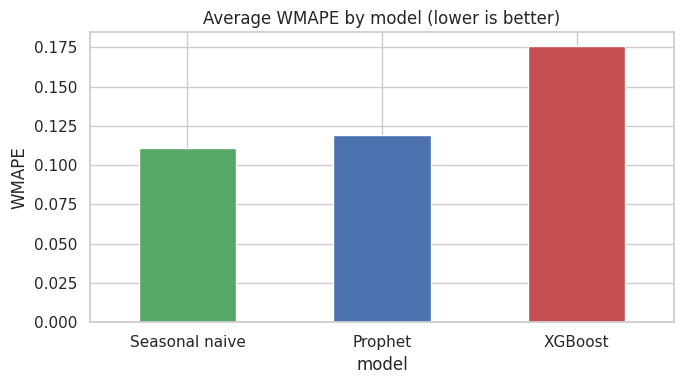

In [4]:
fig, ax = plt.subplots(figsize=(7, 4))
summary["WMAPE"].plot(kind="bar", ax=ax, color=["#55A868", "#4C72B0", "#C44E52"])
ax.set_title("Average WMAPE by model (lower is better)")
ax.set_ylabel("WMAPE")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

**The seasonal-naive baseline holds up surprisingly well** at this level
of aggregation — weekly retail seasonality is strong and stable, so
"same day last week" is a hard baseline to beat. Prophet is competitive.
XGBoost, scored the same way, comes out behind on average here — worth
digging into why rather than stopping at the headline number.

## Where does XGBoost actually struggle?

In [5]:
by_family = results.pivot_table(index="family", columns="model", values="WMAPE")
(by_family * 100).round(1)

model,Prophet,Seasonal naive,XGBoost
family,,,
BEVERAGES,12.9,12.1,10.3
BREAD/BAKERY,9.7,8.3,18.8
CLEANING,10.9,13.2,11.3
DAIRY,9.4,10.0,10.8
GROCERY I,10.6,12.0,11.9
MEATS,13.5,10.6,36.2
POULTRY,10.9,12.9,29.5
PRODUCE,17.7,9.8,11.8


XGBoost is competitive (even the best model) on steadier categories like
**BEVERAGES** and **CLEANING**, but falls apart on **MEATS** and
**POULTRY** — the most volatile, perishable categories.

The reason is the forecasting strategy, not the model itself: this
implementation forecasts **recursively** — each day's prediction becomes
a lag feature for the next day's prediction. Over a 28-day horizon, that
lets errors compound, and it compounds fastest on the noisiest series.
The seasonal-naive and Prophet models don't have this failure mode
because they don't feed their own predictions back in as inputs.

**Practical takeaway, and a documented next step:** a *direct* multi-step
XGBoost (a separate model per forecast horizon, trained only on
information available at the origin date) would remove the compounding
error and is the natural next iteration — noted here rather than quietly
tuned away, because knowing *why* a model underperforms is the useful
part.

## Fold-by-fold stability

In [6]:
by_fold = results.pivot_table(index="fold", columns="model", values="WMAPE")
(by_fold * 100).round(1)

model,Prophet,Seasonal naive,XGBoost
fold,,,
0,13.6,11.4,18.3
1,13.5,11.3,21.2
2,10.0,13.3,14.0
3,10.7,8.5,16.8


## Example: actual vs. forecast (GROCERY I, most recent fold)

03:27:25 - cmdstanpy - INFO - Chain [1] start processing


03:27:26 - cmdstanpy - INFO - Chain [1] done processing


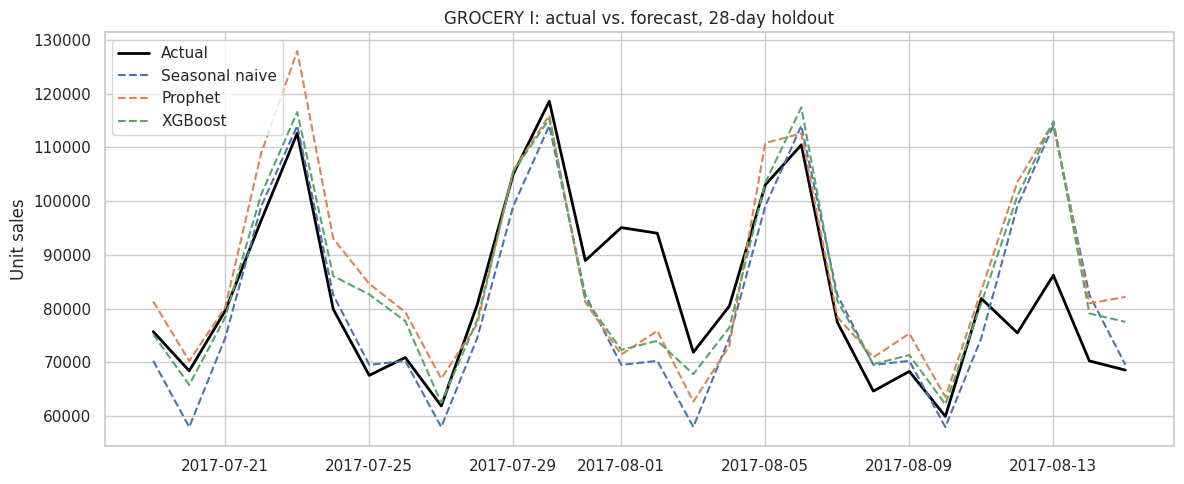

In [7]:
horizon, n_folds = 28, 4
max_date = panel["date"].max()
cutoff = max_date - pd.Timedelta(days=horizon * 1)  # fold 3 (most recent)
family = "GROCERY I"

hist = panel[(panel["family"] == family) & (panel["date"] <= cutoff)]
actual_df = panel[(panel["family"] == family) & (panel["date"] > cutoff) & (panel["date"] <= cutoff + pd.Timedelta(days=horizon))]

base_pred = seasonal_naive_forecast(hist.set_index("date")["unit_sales"], horizon)
train_p = hist.rename(columns={"date": "ds", "unit_sales": "y"})
future_p = actual_df.rename(columns={"date": "ds"})
proph_pred = prophet_forecast(train_p, future_p, horizon)

train_all = panel[panel["date"] <= cutoff]
xgb_model = train_xgboost(add_features(train_all))
xgb_pred = xgboost_forecast(xgb_model, panel, family, cutoff, horizon)

fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(actual_df["date"], actual_df["unit_sales"], label="Actual", color="black", linewidth=2)
ax.plot(actual_df["date"], base_pred, label="Seasonal naive", linestyle="--")
ax.plot(actual_df["date"], proph_pred, label="Prophet", linestyle="--")
ax.plot(actual_df["date"], xgb_pred, label="XGBoost", linestyle="--")
ax.set_title(f"{family}: actual vs. forecast, 28-day holdout")
ax.set_ylabel("Unit sales")
ax.legend()
plt.tight_layout()
plt.show()

## Summary

| Model | MAPE | WMAPE | Bias |
|---|---|---|---|
| Seasonal naive baseline | _see table above_ | _see table above_ | _see table above_ |
| Prophet | _see table above_ | _see table above_ | _see table above_ |
| XGBoost | _see table above_ | _see table above_ | _see table above_ |

(Exact figures are in the "Overall accuracy by model" table above and in
`reports/backtest_results.csv` — kept here as a pointer rather than
duplicated numbers that could drift out of sync.)

## Next: `03_inventory_optimization.ipynb`

Turns these forecasts (and their forecast error, not just the point
estimate) into safety stock and reorder point recommendations, and
quantifies the stockout/overstock cost difference against a
naive-forecast baseline.